# 🚗 Tesla Deliveries — End-to-End ML Pipeline (2015–2025)

**Stages covered:**
1. Data Loading & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Regression Modelling (Linear, Ridge, Random Forest, XGBoost)
5. Hyperparameter Tuning (GridSearchCV)
6. Time Series Forecasting (SARIMA + Prophet-style decomposition)


In [45]:
# Verify required packages are available
import importlib
required = ['xgboost', 'statsmodels', 'sklearn']
for pkg in required:
    assert importlib.util.find_spec(pkg) is not None, f'{pkg} not found'
print('All packages ready ✓')


All packages ready ✓


## 1. Imports & Configuration

In [46]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})
print("Imports complete ✓")


Imports complete ✓


## 2. Data Loading & Preprocessing

In [47]:
from pathlib import Path

csv_path = Path("tesla_deliveries_dataset_2015_2025.csv")
if not csv_path.exists():
    csv_path = next(Path.cwd().glob("tesla_deliveries_dataset_2015_2025*.csv"), None)
    if csv_path is None:
        raise FileNotFoundError(
            "Could not find tesla_deliveries_dataset_2015_2025.csv in the current directory."
        )

print(f"Using dataset: {csv_path}")
df = pd.read_csv(csv_path)
print(f"Shape: {df.shape}")
df.head()

Using dataset: tesla_deliveries_dataset_2015_2025.csv
Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [48]:
print("=== Info ===")
df.info()
print("\n=== Missing values ===")
print(df.isnull().sum())
print("\n=== Descriptive stats ===")
df.describe()


=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 337.3 KB

=== Missing values ===
Year                    0
Month                   0
Region                  0
Model          

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [49]:
# Data types & duplicates
print("Duplicate rows:", df.duplicated().sum())

# Convert Region / Model to category for memory efficiency
for col in ["Region", "Model", "Source_Type"]:
    df[col] = df[col].astype("category")

# Create a proper datetime index
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(day=1))
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

print("Date range:", df["Date"].min().date(), "→", df["Date"].max().date())
df.head()


Duplicate rows: 0
Date range: 2015-01-01 → 2025-12-01


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


## 3. Exploratory Data Analysis (EDA)

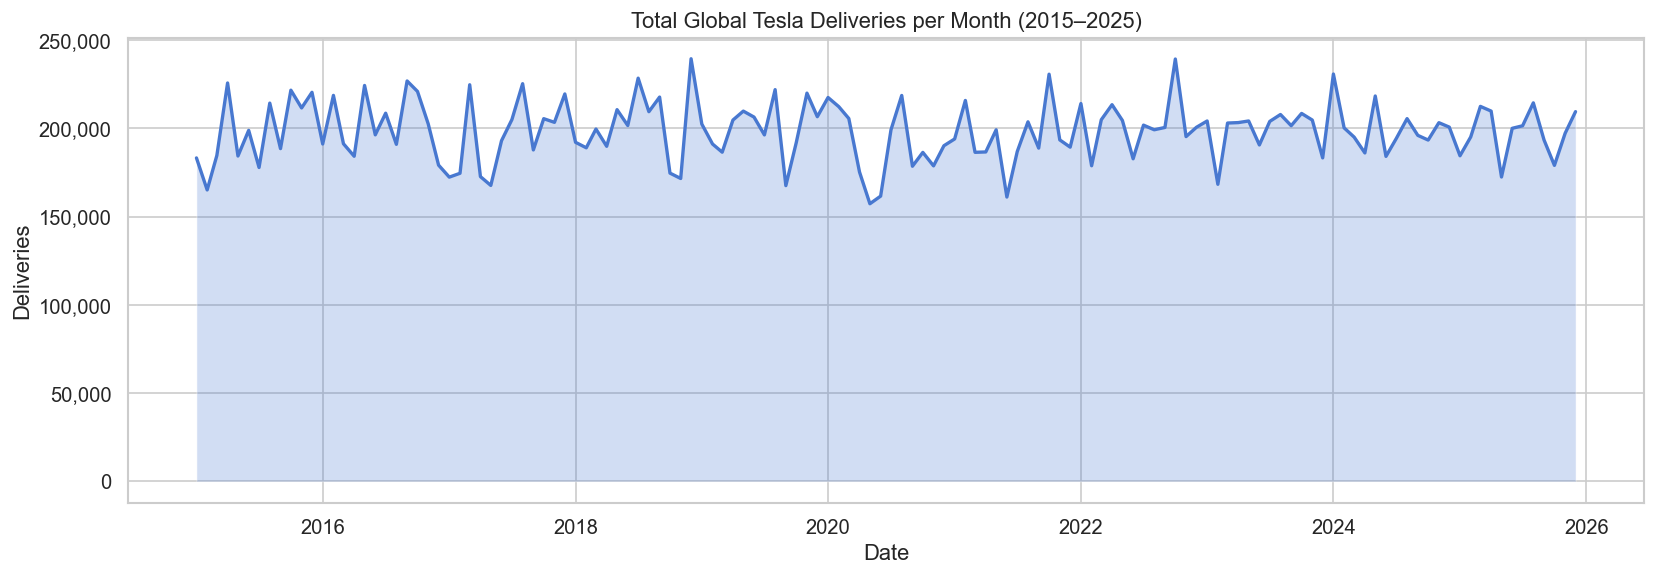

In [50]:
# ── 3.1  Delivery trend over time ──────────────────────────────────────────
monthly = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly["Date"], monthly["Estimated_Deliveries"], alpha=0.25)
ax.plot(monthly["Date"], monthly["Estimated_Deliveries"], linewidth=2)
ax.set_title("Total Global Tesla Deliveries per Month (2015–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Deliveries")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


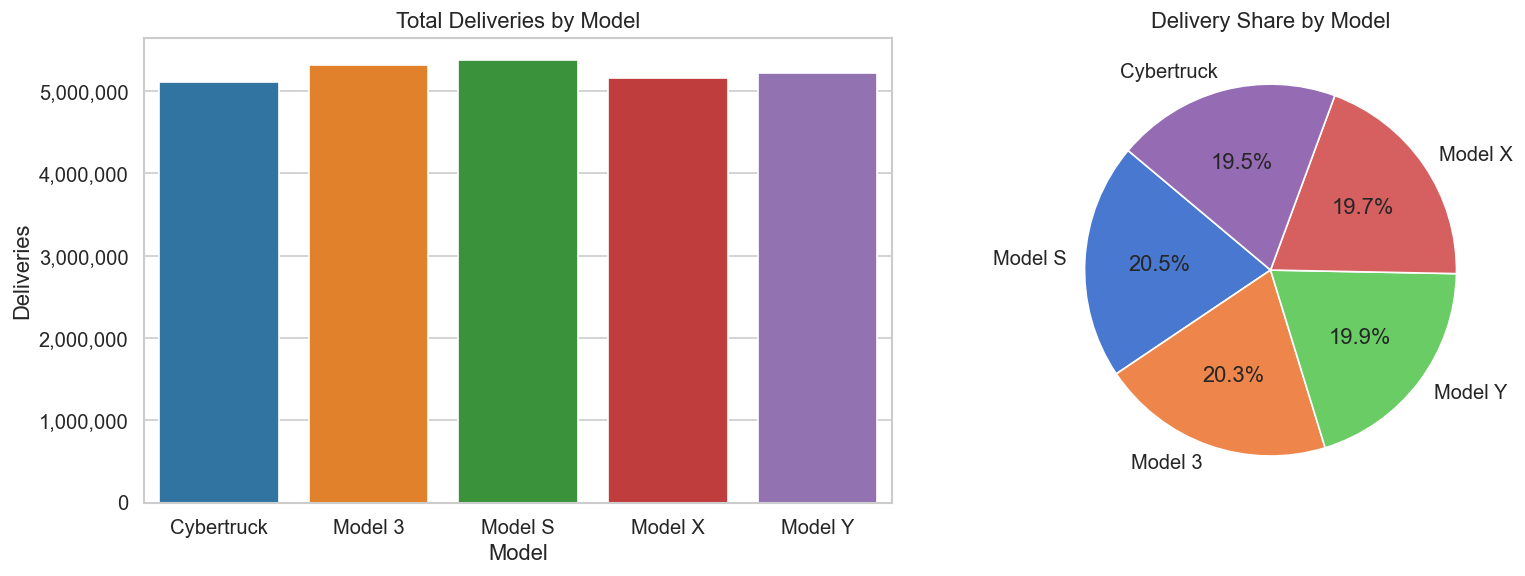

In [51]:
# ── 3.2  Deliveries by Model ───────────────────────────────────────────────
model_total = (df.groupby("Model")["Estimated_Deliveries"]
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(data=model_total, x="Model", y="Estimated_Deliveries",
            palette="tab10", ax=axes[0])
axes[0].set_title("Total Deliveries by Model")
axes[0].set_ylabel("Deliveries")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pie chart
axes[1].pie(model_total["Estimated_Deliveries"], labels=model_total["Model"],
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Delivery Share by Model")

plt.tight_layout()
plt.show()


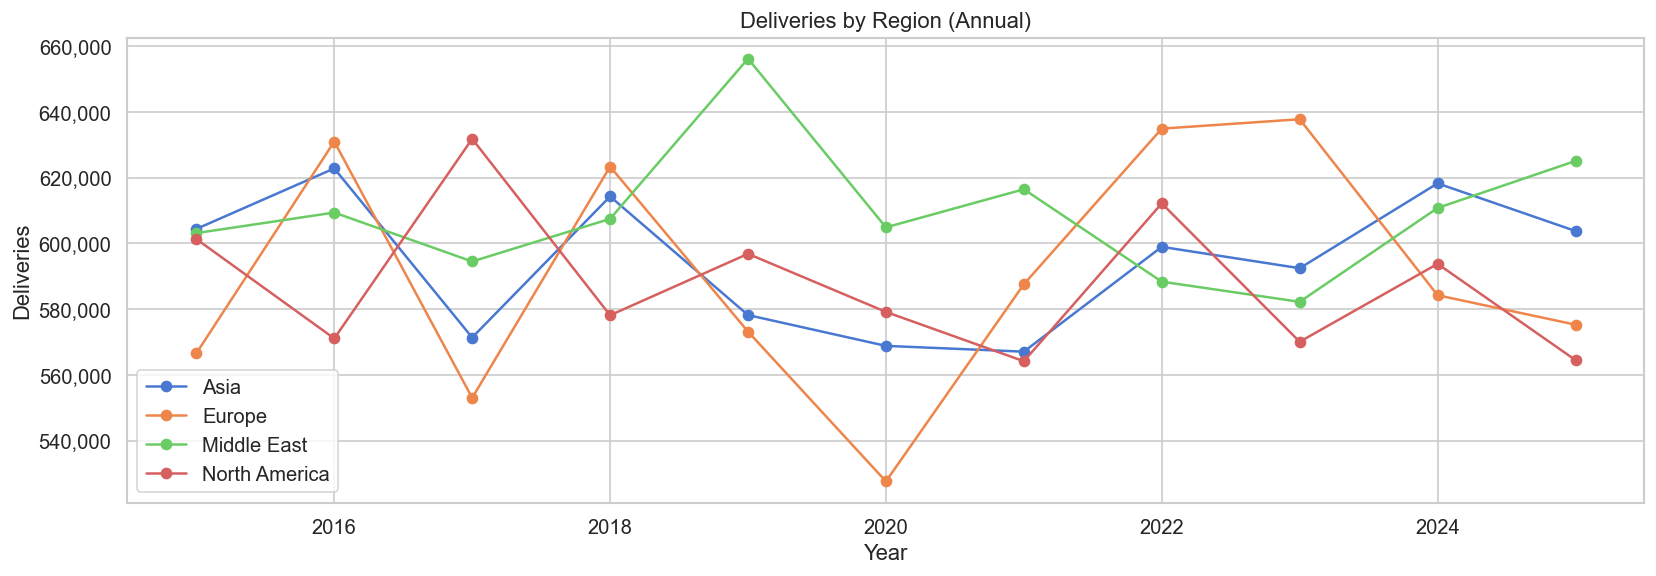

In [52]:
# ── 3.3  Deliveries by Region ──────────────────────────────────────────────
region_year = (df.groupby(["Year", "Region"])["Estimated_Deliveries"]
                 .sum()
                 .reset_index())

fig, ax = plt.subplots(figsize=(14, 5))
for region, grp in region_year.groupby("Region"):
    ax.plot(grp["Year"], grp["Estimated_Deliveries"], marker="o", label=region)
ax.set_title("Deliveries by Region (Annual)")
ax.set_xlabel("Year")
ax.set_ylabel("Deliveries")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
plt.tight_layout()
plt.show()


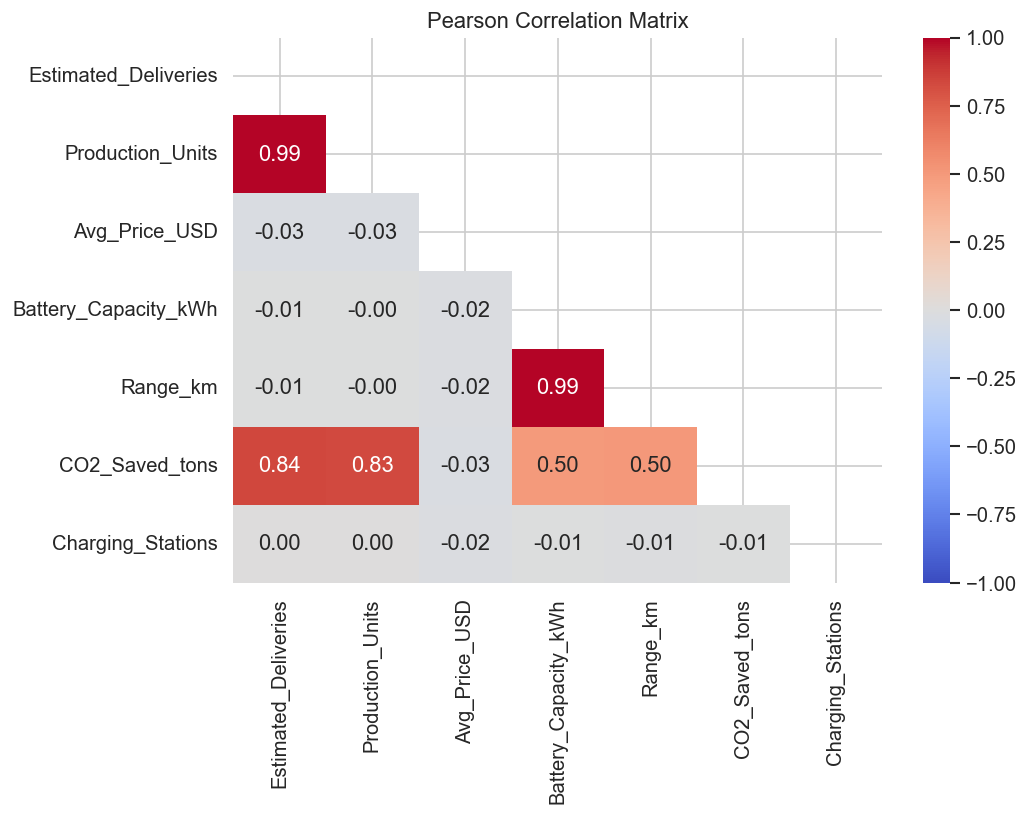

In [53]:
# ── 3.4  Correlation heatmap ───────────────────────────────────────────────
num_cols = ["Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
            "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()


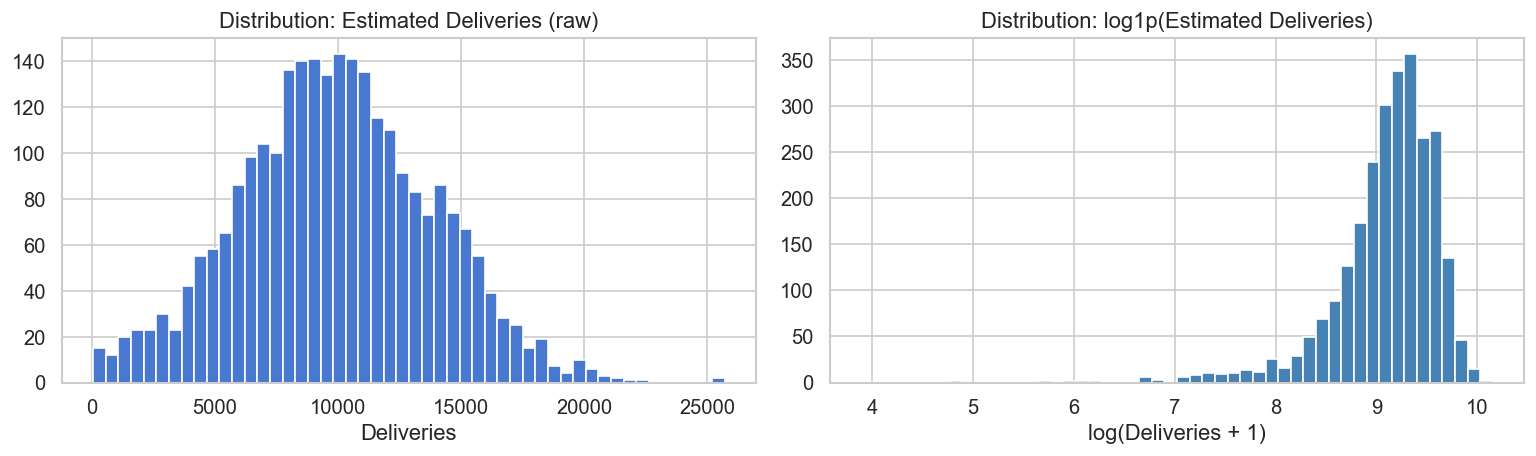

In [54]:
# ── 3.5  Distribution of target variable ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["Estimated_Deliveries"], bins=50, edgecolor="white")
axes[0].set_title("Distribution: Estimated Deliveries (raw)")
axes[0].set_xlabel("Deliveries")

axes[1].hist(np.log1p(df["Estimated_Deliveries"]), bins=50, edgecolor="white", color="steelblue")
axes[1].set_title("Distribution: log1p(Estimated Deliveries)")
axes[1].set_xlabel("log(Deliveries + 1)")

plt.tight_layout()
plt.show()


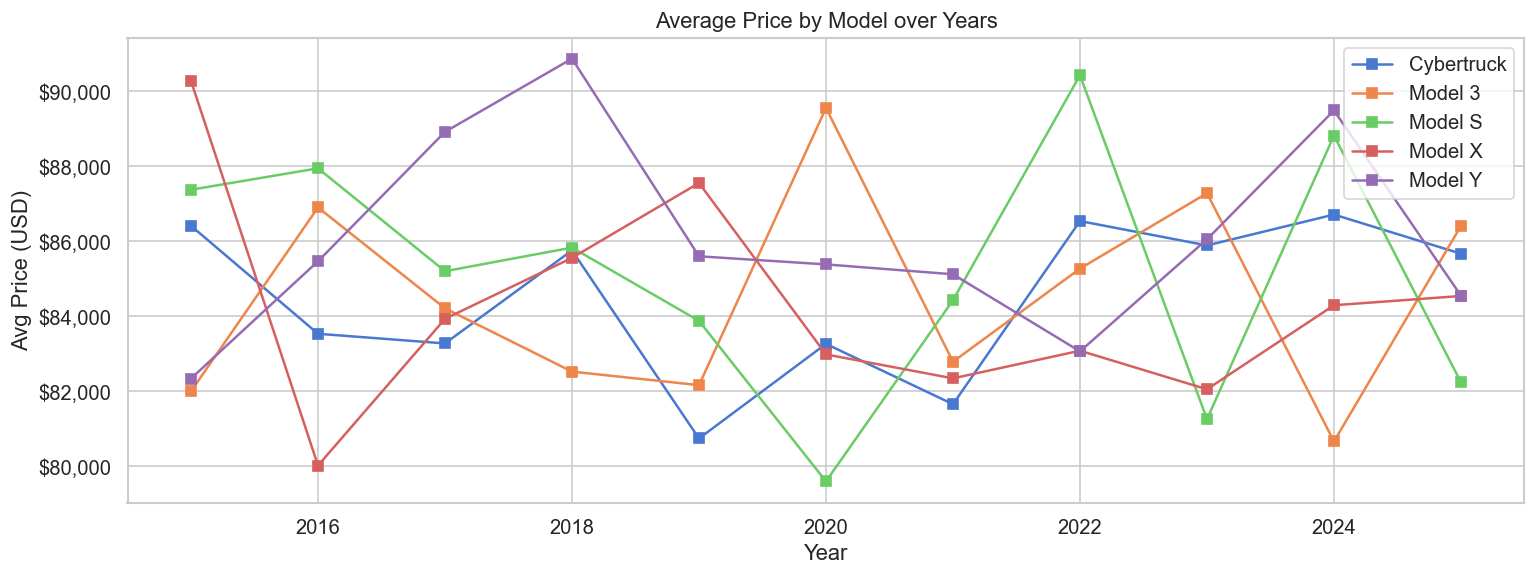

In [55]:
# ── 3.6  Price evolution by model ─────────────────────────────────────────
price_model = df.groupby(["Year", "Model"])["Avg_Price_USD"].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
for model, grp in price_model.groupby("Model"):
    ax.plot(grp["Year"], grp["Avg_Price_USD"], marker="s", label=model)
ax.set_title("Average Price by Model over Years")
ax.set_xlabel("Year")
ax.set_ylabel("Avg Price (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()


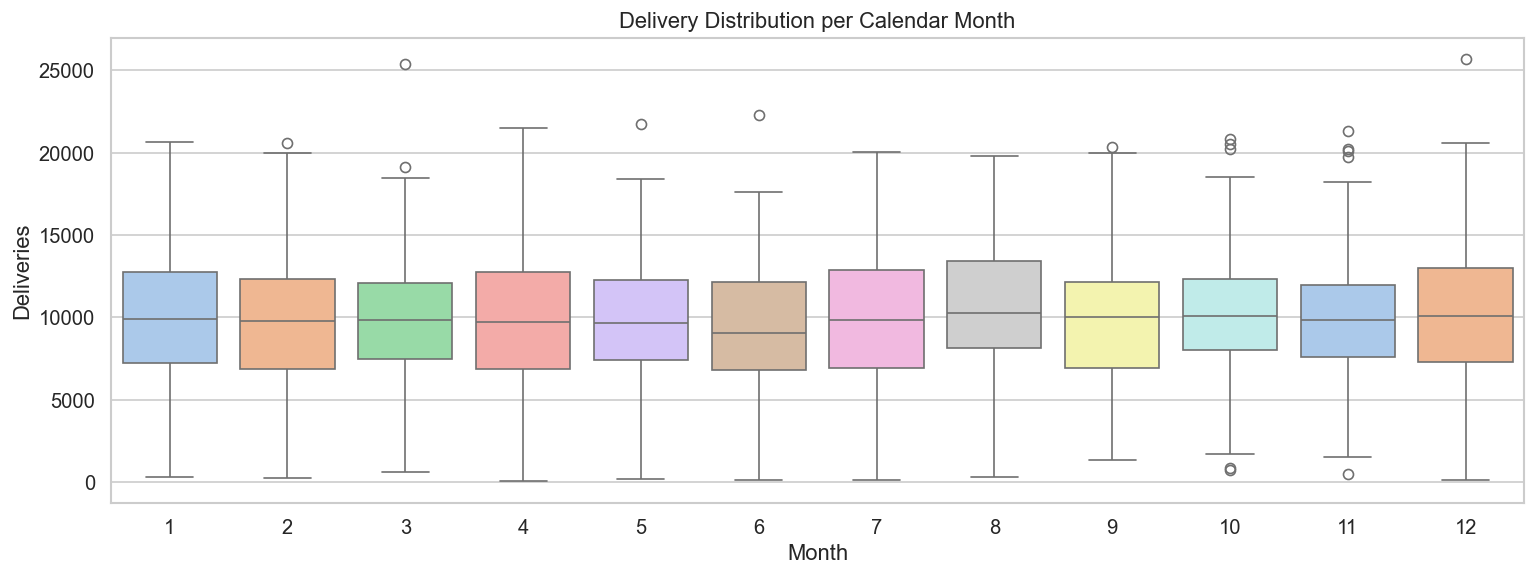

In [56]:
# ── 3.7  Monthly seasonality (box plots) ──────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x="Month", y="Estimated_Deliveries", palette="pastel", ax=ax)
ax.set_title("Delivery Distribution per Calendar Month")
ax.set_xlabel("Month")
ax.set_ylabel("Deliveries")
plt.tight_layout()
plt.show()


## 4. Feature Engineering

In [57]:
fe = df.copy()

# ── Temporal features ──────────────────────────────────────────────────────
fe["Quarter"]    = fe["Date"].dt.quarter
fe["Is_Q4"]      = (fe["Quarter"] == 4).astype(int)
fe["Year_Norm"]  = fe["Year"] - fe["Year"].min()        # years since 2015

# ── Cyclical encoding for Month ────────────────────────────────────────────
fe["Month_sin"]  = np.sin(2 * np.pi * fe["Month"] / 12)
fe["Month_cos"]  = np.cos(2 * np.pi * fe["Month"] / 12)

# ── Derived ratios ─────────────────────────────────────────────────────────
fe["Efficiency_km_per_kWh"] = fe["Range_km"] / fe["Battery_Capacity_kWh"]
fe["Utilisation_Rate"]      = fe["Estimated_Deliveries"] / fe["Production_Units"].replace(0, np.nan)
fe["CO2_per_Delivery"]      = fe["CO2_Saved_tons"] / fe["Estimated_Deliveries"].replace(0, np.nan)

# ── Label encoding ─────────────────────────────────────────────────────────
le_region = LabelEncoder()
le_model  = LabelEncoder()
fe["Region_enc"] = le_region.fit_transform(fe["Region"].astype(str))
fe["Model_enc"]  = le_model.fit_transform(fe["Model"].astype(str))

# ── Log-transform target ───────────────────────────────────────────────────
fe["log_Deliveries"] = np.log1p(fe["Estimated_Deliveries"])

print("New features added:")
new_cols = ["Quarter","Is_Q4","Year_Norm","Month_sin","Month_cos",
            "Efficiency_km_per_kWh","Utilisation_Rate","CO2_per_Delivery",
            "Region_enc","Model_enc","log_Deliveries"]
print(new_cols)
fe[new_cols].describe()


New features added:
['Quarter', 'Is_Q4', 'Year_Norm', 'Month_sin', 'Month_cos', 'Efficiency_km_per_kWh', 'Utilisation_Rate', 'CO2_per_Delivery', 'Region_enc', 'Model_enc', 'log_Deliveries']


,Quarter,Is_Q4,Year_Norm,Month_sin,Month_cos,Efficiency_km_per_kWh,Utilisation_Rate,CO2_per_Delivery,Region_enc,Model_enc,log_Deliveries
count,2640.000000,2640.000000,2640.000000,2.640000e+03,2.640000e+03,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2.500000,0.250000,5.000000,0.000000e+00,-8.343494e-17,5.744712,0.932619,0.075039,1.500000,2.000000,9.088670
std,1.118246,0.433095,3.162877,7.072407e-01,7.072407e-01,0.144847,0.037232,0.018130,1.118246,1.414481,0.566626
min,1.000000,0.000000,0.000000,-1.000000e+00,-1.000000e+00,5.493333,0.869683,0.049500,0.000000,0.000000,3.891820
25%,1.750000,0.000000,2.000000,-5.915064e-01,-5.915064e-01,5.616667,0.899904,0.062701,0.750000,1.000000,8.894670
50%,2.500000,0.000000,5.000000,-6.123234e-17,-6.123234e-17,5.750000,0.932176,0.070500,1.500000,2.000000,9.196039
75%,3.250000,0.250000,8.000000,5.915064e-01,5.915064e-01,5.866667,0.964178,0.087938,2.250000,3.000000,9.434383
max,4.000000,1.000000,10.000000,1.000000e+00,1.000000e+00,5.991667,1.000000,0.107850,3.000000,4.000000,10.154441


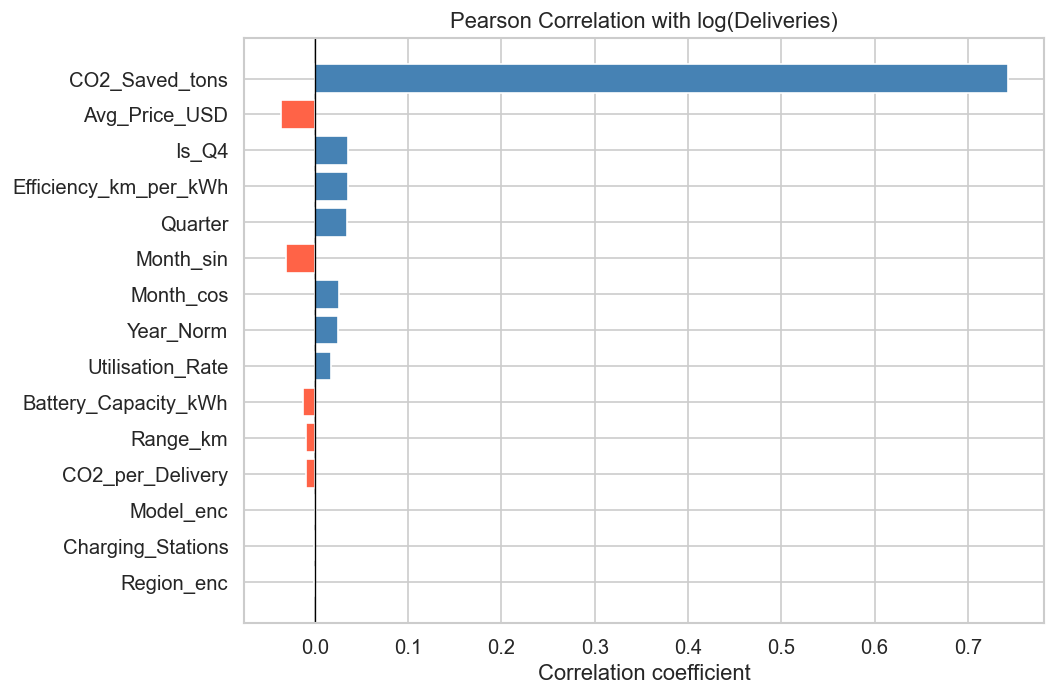

In [58]:
# ── Feature importance preview (correlation with target) ───────────────────
feature_cols = ["Year_Norm","Quarter","Is_Q4","Month_sin","Month_cos",
                "Avg_Price_USD","Battery_Capacity_kWh","Range_km",
                "CO2_Saved_tons","Charging_Stations","Efficiency_km_per_kWh",
                "Utilisation_Rate","CO2_per_Delivery","Region_enc","Model_enc"]

# drop any NaN rows (from division)
fe_clean = fe[feature_cols + ["log_Deliveries"]].dropna()

corrs = {f: pearsonr(fe_clean[f], fe_clean["log_Deliveries"])[0] for f in feature_cols}
corr_s = pd.Series(corrs).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["steelblue" if v >= 0 else "tomato" for v in corr_s.values]
ax.barh(corr_s.index[::-1], corr_s.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with log(Deliveries)")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()


## 5. Regression Modelling

In [59]:
# ── Train / test split ─────────────────────────────────────────────────────
TARGET = "log_Deliveries"
FEATURES = feature_cols      # defined above

data_model = fe_clean.copy()
X = data_model[FEATURES]
y = data_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (2112, 15), Test: (528, 15)


In [60]:
# ── Helper: evaluation metrics ─────────────────────────────────────────────
import time

def evaluate(name, model, X_tr, y_tr, X_te, y_te, cv_folds=3):
    start = time.time()
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae   = mean_absolute_error(y_te, preds)
    rmse  = mean_squared_error(y_te, preds) ** 0.5
    r2    = r2_score(y_te, preds)
    cv    = cross_val_score(model, X_tr, y_tr, cv=cv_folds, scoring="r2", n_jobs=1).mean()
    elapsed = time.time() - start
    return {"Model": name, "MAE": round(mae, 4), "RMSE": round(rmse, 4),
            "R2_test": round(r2, 4), "R2_CV_mean": round(cv, 4), "Time_s": round(elapsed, 2)}

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

results = []


In [61]:
# ── 5.1  Linear Regression ─────────────────────────────────────────────────
lr = LinearRegression()
results.append(evaluate("Linear Regression", lr, X_train_s, y_train, X_test_s, y_test))
print(results[-1])


{'Model': 'Linear Regression', 'MAE': 0.1767, 'RMSE': 0.5625, 'R2_test': 0.1754, 'R2_CV_mean': np.float64(0.7952), 'Time_s': 0.08}


In [62]:
# ── 5.2  Ridge Regression ──────────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
results.append(evaluate("Ridge", ridge, X_train_s, y_train, X_test_s, y_test))
print(results[-1])


{'Model': 'Ridge', 'MAE': 0.1664, 'RMSE': 0.3446, 'R2_test': 0.6905, 'R2_CV_mean': np.float64(0.7657), 'Time_s': 0.06}


In [63]:
# ── 5.3  Lasso Regression ──────────────────────────────────────────────────
lasso = Lasso(alpha=0.01, max_iter=5000)
results.append(evaluate("Lasso", lasso, X_train_s, y_train, X_test_s, y_test))
print(results[-1])


{'Model': 'Lasso', 'MAE': 0.1636, 'RMSE': 0.3447, 'R2_test': 0.6903, 'R2_CV_mean': np.float64(0.7641), 'Time_s': 0.06}


In [64]:
# ── 5.4  Random Forest ─────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1)
results.append(evaluate("Random Forest", rf, X_train, y_train, X_test, y_test))
print(results[-1])


{'Model': 'Random Forest', 'MAE': 0.0191, 'RMSE': 0.0755, 'R2_test': 0.9852, 'R2_CV_mean': np.float64(0.9922), 'Time_s': 14.2}


In [65]:
# ── 5.5  Gradient Boosting ─────────────────────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                               max_depth=5, random_state=42)
results.append(evaluate("Gradient Boosting", gb, X_train, y_train, X_test, y_test))
print(results[-1])


{'Model': 'Gradient Boosting', 'MAE': 0.0159, 'RMSE': 0.0654, 'R2_test': 0.9889, 'R2_CV_mean': np.float64(0.9944), 'Time_s': 7.03}


In [66]:
# ── 5.6  XGBoost ───────────────────────────────────────────────────────────
xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=42, verbosity=0)
results.append(evaluate("XGBoost", xgb, X_train, y_train, X_test, y_test))
print(results[-1])


{'Model': 'XGBoost', 'MAE': 0.0287, 'RMSE': 0.1207, 'R2_test': 0.962, 'R2_CV_mean': np.float64(0.9842), 'Time_s': 0.91}


            Model    MAE   RMSE  R2_test  R2_CV_mean  Time_s
Gradient Boosting 0.0159 0.0654   0.9889      0.9944    7.03
    Random Forest 0.0191 0.0755   0.9852      0.9922   14.20
          XGBoost 0.0287 0.1207   0.9620      0.9842    0.91
            Ridge 0.1664 0.3446   0.6905      0.7657    0.06
            Lasso 0.1636 0.3447   0.6903      0.7641    0.06
Linear Regression 0.1767 0.5625   0.1754      0.7952    0.08


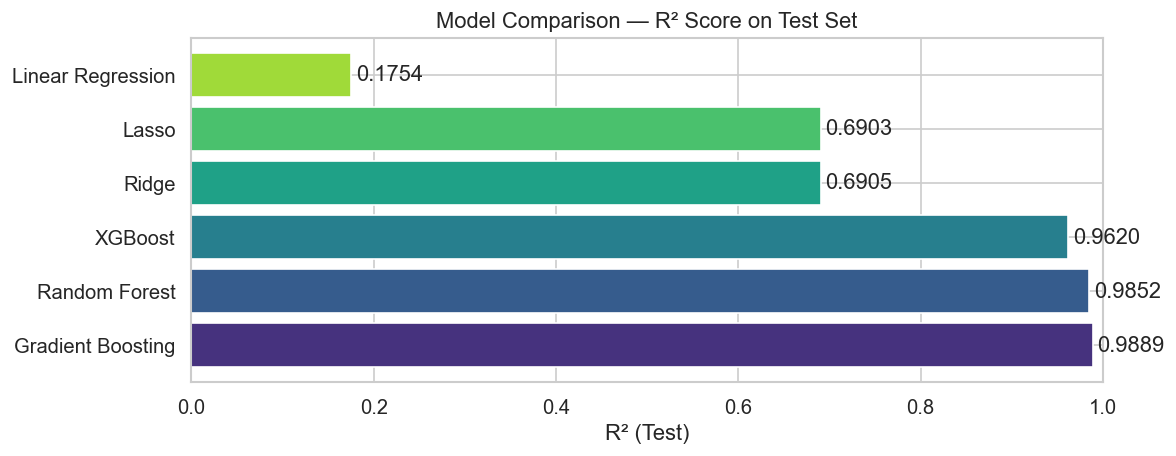

In [67]:
# ── 5.7  Model comparison ──────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values("R2_test", ascending=False)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = sns.color_palette("viridis", len(results_df))
ax.barh(results_df["Model"], results_df["R2_test"], color=bar_colors)
ax.set_xlabel("R² (Test)")
ax.set_title("Model Comparison — R² Score on Test Set")
ax.set_xlim(0, 1)
for i, v in enumerate(results_df["R2_test"]):
    ax.text(v + 0.005, i, f"{v:.4f}", va="center")
plt.tight_layout()
plt.show()


Best model: Gradient Boosting


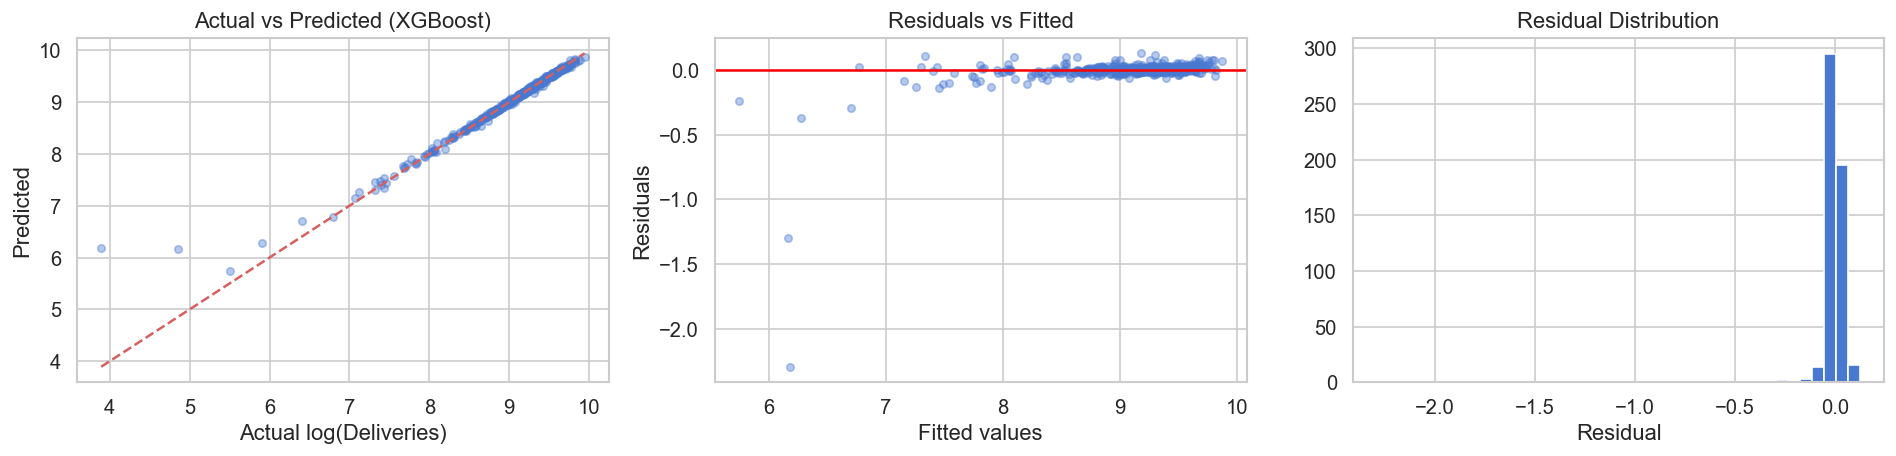

In [68]:
# ── 5.8  Residual analysis for best model ─────────────────────────────────
best_name = results_df.iloc[0]["Model"]
print(f"Best model: {best_name}")

# Re-fit XGBoost (usually best)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, s=20)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5)
axes[0].set_title("Actual vs Predicted (XGBoost)")
axes[0].set_xlabel("Actual log(Deliveries)")
axes[0].set_ylabel("Predicted")

# Residuals vs Fitted
axes[1].scatter(y_pred, residuals, alpha=0.4, s=20)
axes[1].axhline(0, color="red", linewidth=1.5)
axes[1].set_title("Residuals vs Fitted")
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")

# Residual distribution
axes[2].hist(residuals, bins=40, edgecolor="white")
axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residual")

plt.tight_layout()
plt.show()


## 6. Feature Importance

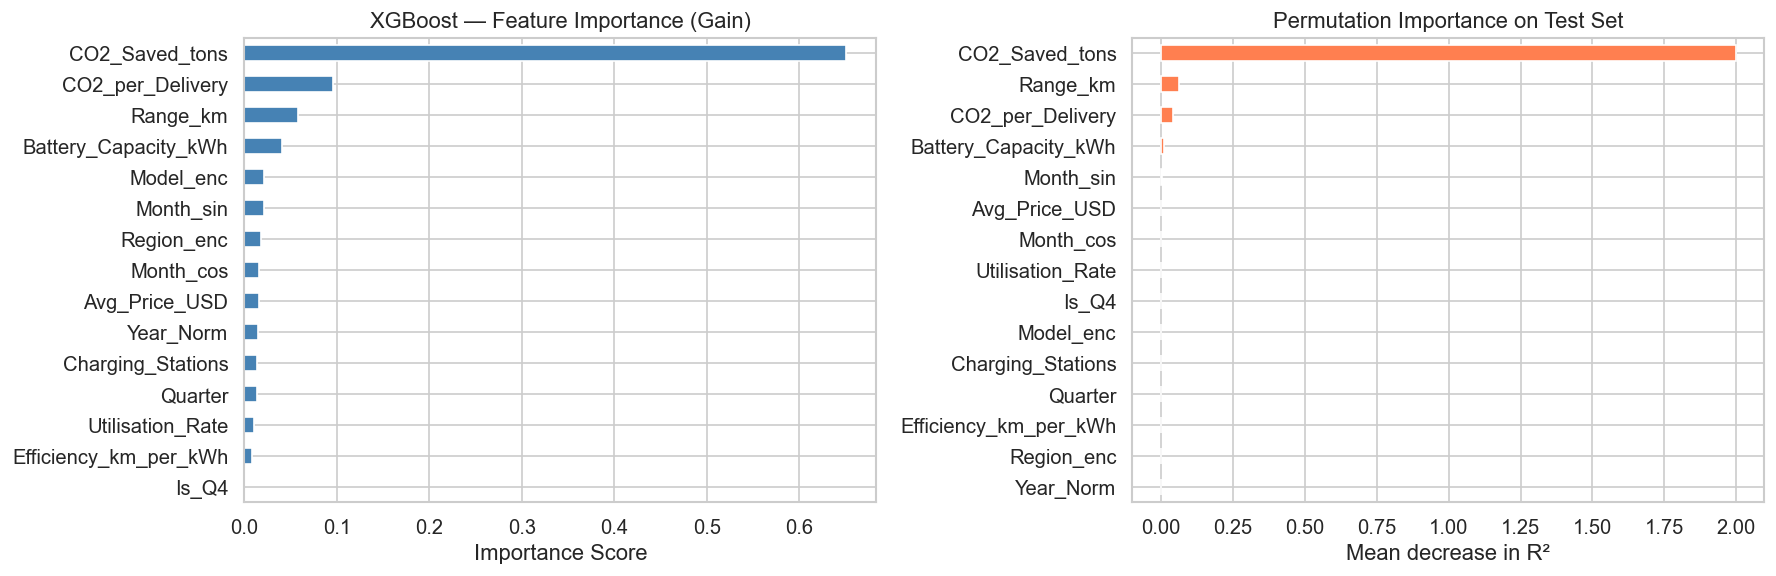

In [69]:
# XGBoost built-in importance
feat_imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Built-in
feat_imp.sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("XGBoost — Feature Importance (Gain)")
axes[0].set_xlabel("Importance Score")

# Permutation importance
perm_imp = permutation_importance(xgb, X_test, y_test, n_repeats=10,
                                  random_state=42, n_jobs=1)
perm_s = pd.Series(perm_imp.importances_mean, index=FEATURES).sort_values()
perm_s.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Permutation Importance on Test Set")
axes[1].set_xlabel("Mean decrease in R²")

plt.tight_layout()
plt.show()


## 7. Hyperparameter Tuning (GridSearchCV)

In [70]:
# Tune Random Forest (fast search)
param_grid = {
    "n_estimators": [50, 100],
    "max_depth":    [None, 10],
    "min_samples_split": [2, 5],
}

rf_tuned = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid, cv=3, scoring="r2", verbose=0, n_jobs=1
)
rf_tuned.fit(X_train, y_train)
best_params = rf_tuned.best_params_
best_score  = rf_tuned.best_score_

print(f"Best params : {best_params}")
print(f"Best CV R²  : {best_score:.4f}")

# Evaluate on test
preds_tuned = rf_tuned.best_estimator_.predict(X_test)
print(f"Tuned RF — Test R²: {r2_score(y_test, preds_tuned):.4f}  "
      f"RMSE: {mean_squared_error(y_test, preds_tuned) ** 0.5:.4f}")


Best params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R²  : 0.9924
Tuned RF — Test R²: 0.9844  RMSE: 0.0774


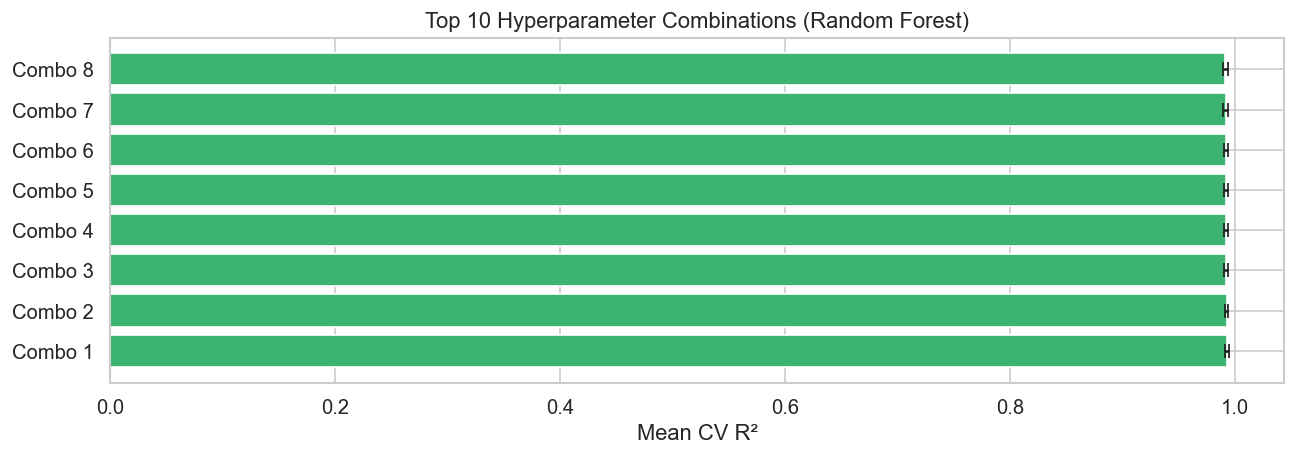

In [71]:
# GridSearch results visualisation
cv_res = pd.DataFrame(rf_tuned.cv_results_)
top10 = cv_res.sort_values("mean_test_score", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(range(len(top10)), top10["mean_test_score"].values, xerr=top10["std_test_score"].values,
        color="mediumseagreen", capsize=4)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([f"Combo {i+1}" for i in range(len(top10))])
ax.set_xlabel("Mean CV R²")
ax.set_title("Top 10 Hyperparameter Combinations (Random Forest)")
plt.tight_layout()
plt.show()


## 8. Time Series Forecasting

In [72]:
# Aggregate to monthly global deliveries
ts = (df.groupby("Date")["Estimated_Deliveries"]
        .sum()
        .asfreq("MS")                          # month-start frequency
        .ffill())               # fill any gaps

print(f"Time series length: {len(ts)} months")
ts.head()


Time series length: 132 months


Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Freq: MS, Name: Estimated_Deliveries, dtype: int64

In [73]:
# ── 8.1  Stationarity check (ADF test) ────────────────────────────────────
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(ts)
print(f"ADF Statistic : {adf_stat:.4f}")
print(f"p-value       : {adf_p:.4f}")
print(f"Critical vals : {adf_crit}")
print("\nConclusion:", "Stationary" if adf_p < 0.05 else "Non-stationary (needs differencing)")


ADF Statistic : -8.8810
p-value       : 0.0000
Critical vals : {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}

Conclusion: Stationary


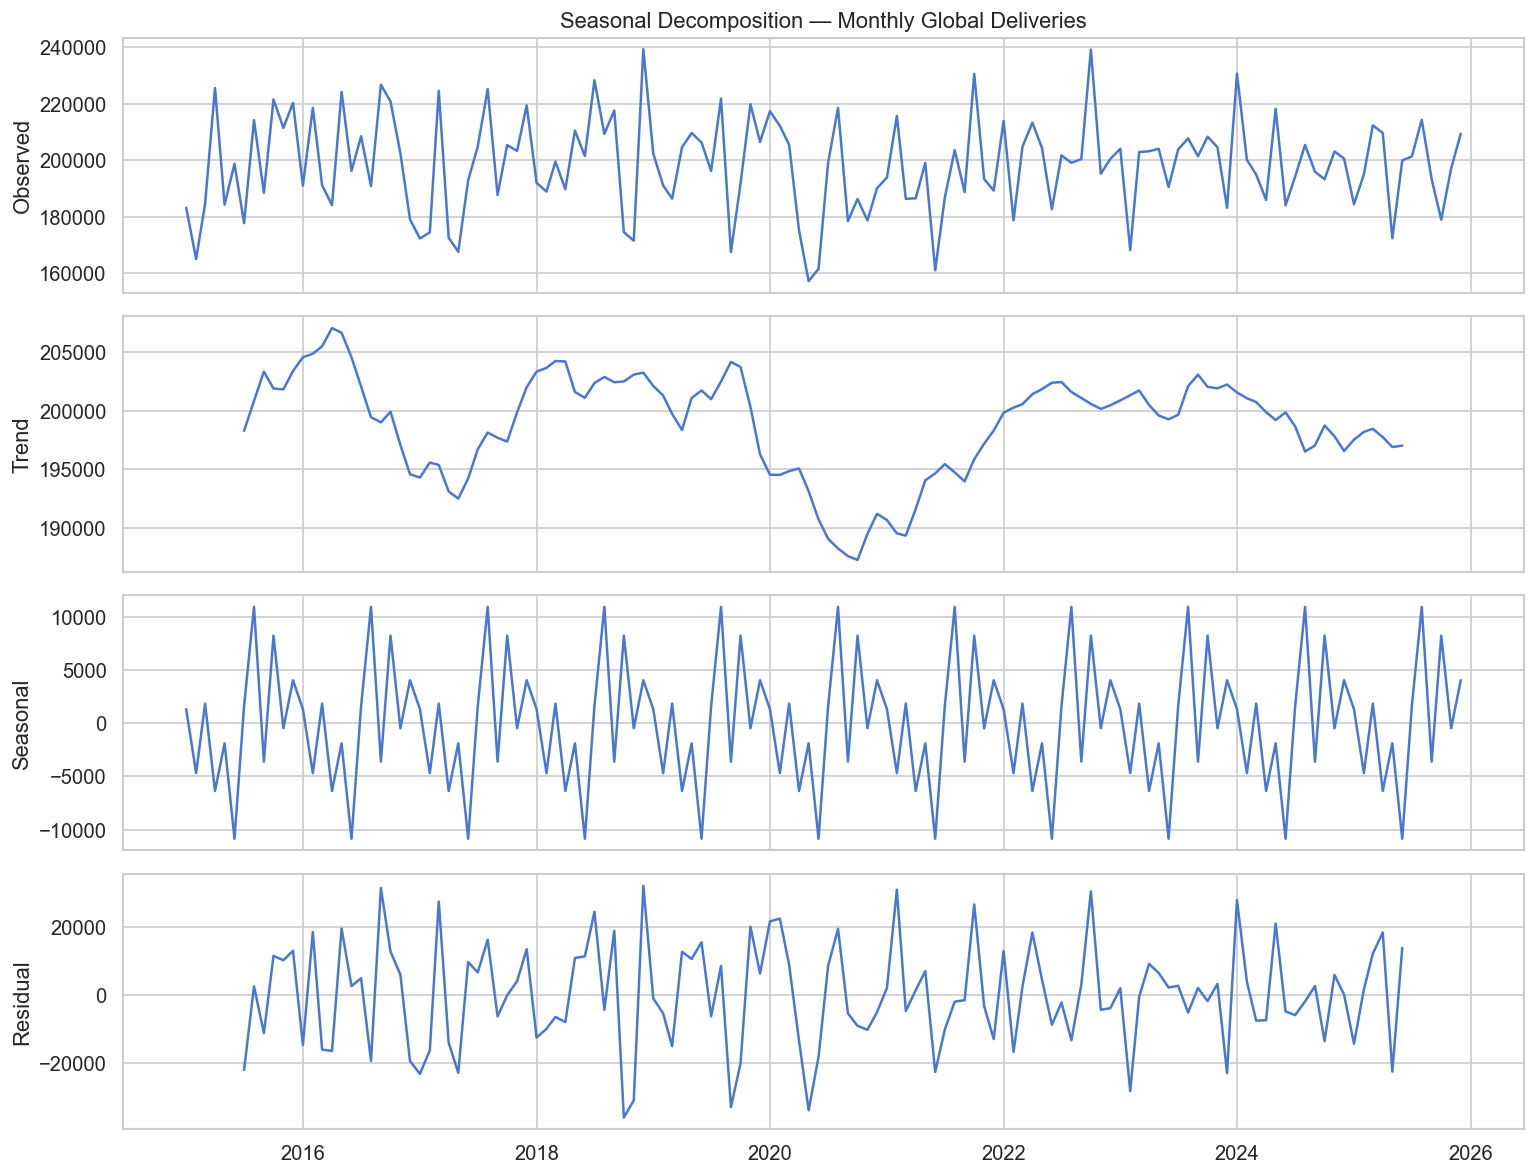

In [74]:
# ── 8.2  Seasonal decomposition ────────────────────────────────────────────
decomp = seasonal_decompose(ts, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for ax, component, label in zip(axes,
                                [ts, decomp.trend, decomp.seasonal, decomp.resid],
                                ["Observed", "Trend", "Seasonal", "Residual"]):
    ax.plot(component)
    ax.set_ylabel(label)
axes[0].set_title("Seasonal Decomposition — Monthly Global Deliveries")
plt.tight_layout()
plt.show()


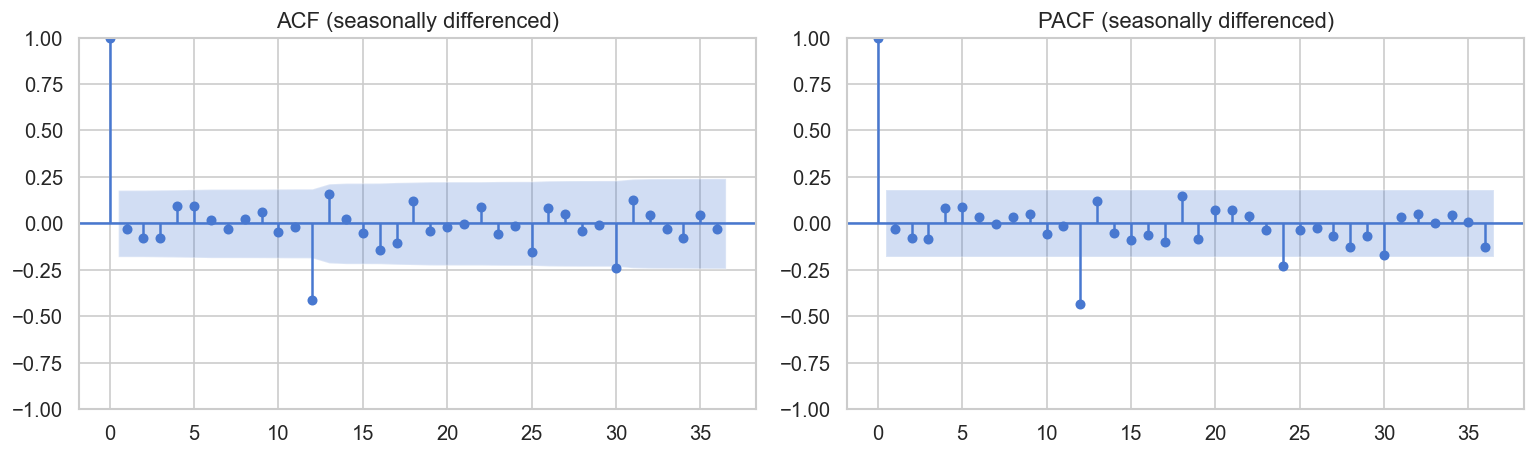

In [75]:
# ── 8.3  ACF / PACF plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(ts.diff(12).dropna(), lags=36, ax=axes[0])
plot_pacf(ts.diff(12).dropna(), lags=36, ax=axes[1], method="ywm")
axes[0].set_title("ACF (seasonally differenced)")
axes[1].set_title("PACF (seasonally differenced)")
plt.tight_layout()
plt.show()


In [76]:
# ── 8.4  SARIMA forecast ───────────────────────────────────────────────────
TRAIN_END = "2024-06-01"
TEST_START = "2024-07-01"
FORECAST_MONTHS = 12

ts_train = ts[:TRAIN_END]
ts_test  = ts[TEST_START:]

# Fit SARIMA(1,1,1)(1,1,0,12)
sarima = SARIMAX(ts_train,
                 order=(1, 1, 1),
                 seasonal_order=(1, 1, 0, 12),
                 enforce_stationarity=False,
                 enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary().tables[0])


                                      SARIMAX Results                                      
Dep. Variable:                Estimated_Deliveries   No. Observations:                  114
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood               -1008.303
Date:                             Sun, 31 May 2026   AIC                           2024.607
Time:                                     09:54:50   BIC                           2034.516
Sample:                                 01-01-2015   HQIC                          2028.599
                                      - 06-01-2024                                         
Covariance Type:                               opg                                         


In [77]:
# ── 8.5  In-sample + out-of-sample predictions ─────────────────────────────
n_forecast = len(ts_test) + FORECAST_MONTHS
forecast_obj = sarima_fit.get_forecast(steps=n_forecast)
fc_mean = forecast_obj.predicted_mean
fc_ci   = forecast_obj.conf_int()

# Split into test period and future
fc_test   = fc_mean.iloc[:len(ts_test)]
fc_future = fc_mean.iloc[len(ts_test):]
ci_test   = fc_ci.iloc[:len(ts_test)]
ci_future = fc_ci.iloc[len(ts_test):]

# Metrics on test period
if len(ts_test) > 0:
    mae_ts  = mean_absolute_error(ts_test, fc_test)
    rmse_ts = mean_squared_error(ts_test, fc_test) ** 0.5
    r2_ts   = r2_score(ts_test, fc_test)
    print(f"SARIMA on hold-out — MAE: {mae_ts:,.0f}  RMSE: {rmse_ts:,.0f}  R²: {r2_ts:.4f}")


SARIMA on hold-out — MAE: 14,839  RMSE: 19,524  R²: -2.2375


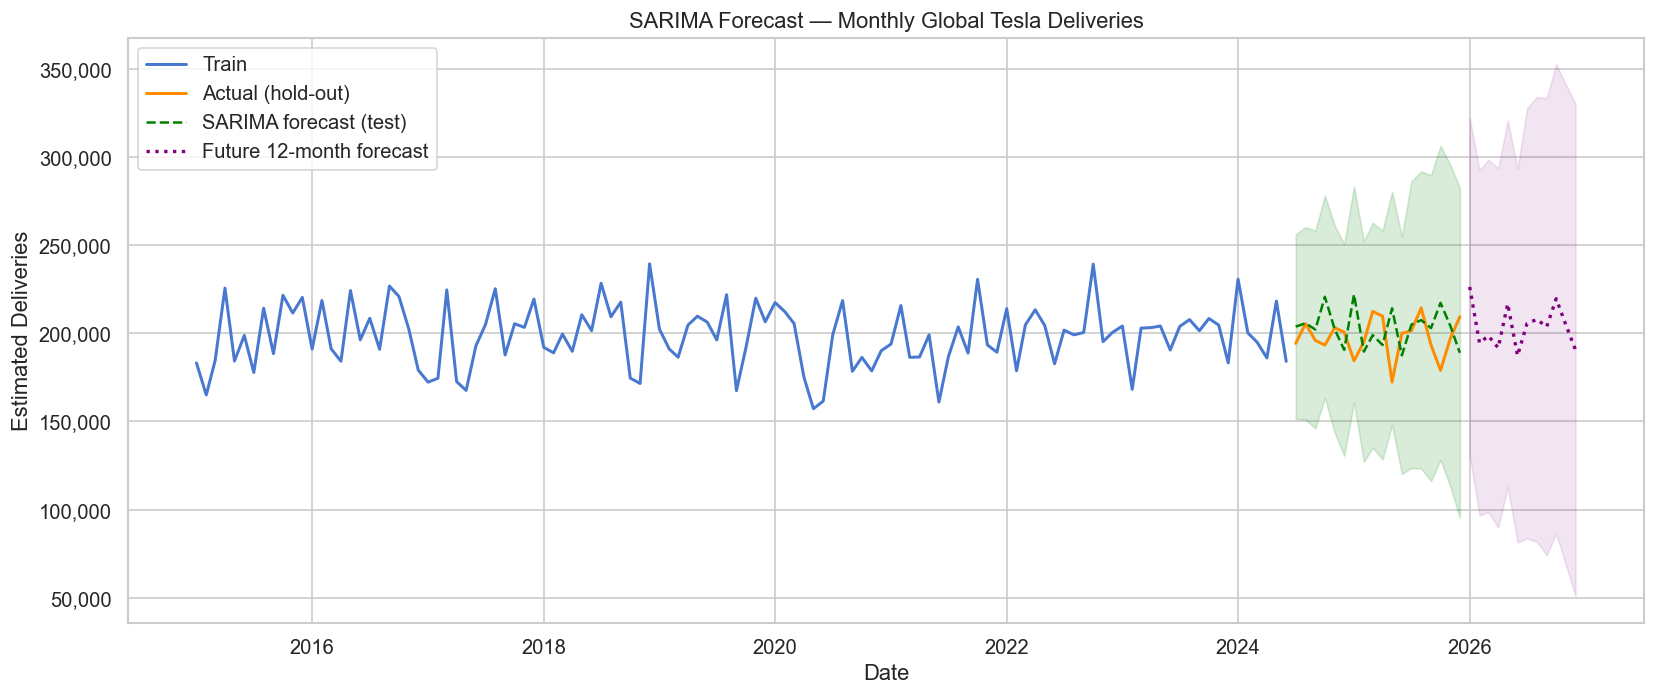

In [78]:
# ── 8.6  Plot forecast ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# History
ax.plot(ts_train, label="Train", linewidth=1.8)
ax.plot(ts_test,  label="Actual (hold-out)", linewidth=1.8, color="darkorange")

# Test-period forecast
ax.plot(fc_test, label="SARIMA forecast (test)", linestyle="--", color="green")
ax.fill_between(ci_test.index, ci_test.iloc[:, 0], ci_test.iloc[:, 1],
                alpha=0.15, color="green")

# Future forecast
ax.plot(fc_future, label=f"Future {FORECAST_MONTHS}-month forecast",
        linestyle=":", color="purple", linewidth=2)
ax.fill_between(ci_future.index, ci_future.iloc[:, 0], ci_future.iloc[:, 1],
                alpha=0.10, color="purple")

ax.set_title("SARIMA Forecast — Monthly Global Tesla Deliveries")
ax.set_xlabel("Date")
ax.set_ylabel("Estimated Deliveries")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
plt.tight_layout()
plt.show()


In [79]:
# ── 8.7  Forecast table ────────────────────────────────────────────────────
fc_table = pd.DataFrame({
    "Forecast":  fc_future.values.round(0).astype(int),
    "Lower_95":  ci_future.iloc[:, 0].values.round(0).astype(int),
    "Upper_95":  ci_future.iloc[:, 1].values.round(0).astype(int),
}, index=fc_future.index)
fc_table.index.name = "Month"
print(f"\n12-Month Delivery Forecast (starting {fc_future.index[0].date()}):")
print(fc_table.to_string())



12-Month Delivery Forecast (starting 2026-01-01):
            Forecast  Lower_95  Upper_95
Month                                   
2026-01-01    226264    130584    321944
2026-02-01    194518     96715    292320
2026-03-01    198540     98660    298420
2026-04-01    191724     89809    293639
2026-05-01    216706    112796    320616
2026-06-01    187291     81424    293159
2026-07-01    205535     83616    327454
2026-08-01    207869     81786    333953
2026-09-01    203700     74104    333296
2026-10-01    219562     86584    352540
2026-11-01    204537     68264    340810
2026-12-01    190598     51107    330088


## 9. Pipeline Summary

In [80]:
print("=" * 60)
print("   TESLA ML PIPELINE — FINAL SUMMARY")
print("=" * 60)
print(f"\nDataset     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range  : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Models      : {df['Model'].cat.categories.tolist()}")
print(f"Regions     : {df['Region'].cat.categories.tolist()}")

print("\n── Regression results (log-scale target) ──")
print(results_df.to_string(index=False))

print("\n── Tuned Random Forest ──")
print(f"  Best params : {best_params}")
print(f"  Test R²     : {r2_score(y_test, preds_tuned):.4f}")

if len(ts_test) > 0:
    print("\n── SARIMA Time Series ──")
    print(f"  Hold-out MAE  : {mae_ts:,.0f}")
    print(f"  Hold-out RMSE : {rmse_ts:,.0f}")
    print(f"  Hold-out R²   : {r2_ts:.4f}")

print("\n✅ End-to-end pipeline complete!")


   TESLA ML PIPELINE — FINAL SUMMARY

Dataset     : 2,640 rows × 13 columns
Date range  : 2015-01-01 → 2025-12-01
Models      : ['Cybertruck', 'Model 3', 'Model S', 'Model X', 'Model Y']
Regions     : ['Asia', 'Europe', 'Middle East', 'North America']

── Regression results (log-scale target) ──
            Model    MAE   RMSE  R2_test  R2_CV_mean  Time_s
Gradient Boosting 0.0159 0.0654   0.9889      0.9944    7.03
    Random Forest 0.0191 0.0755   0.9852      0.9922   14.20
          XGBoost 0.0287 0.1207   0.9620      0.9842    0.91
            Ridge 0.1664 0.3446   0.6905      0.7657    0.06
            Lasso 0.1636 0.3447   0.6903      0.7641    0.06
Linear Regression 0.1767 0.5625   0.1754      0.7952    0.08

── Tuned Random Forest ──
  Best params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  Test R²     : 0.9844

── SARIMA Time Series ──
  Hold-out MAE  : 14,839
  Hold-out RMSE : 19,524
  Hold-out R²   : -2.2375

✅ End-to-end pipeline complete!
